In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Customer Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df['TotalCharges'] = df['TotalCharges'].replace(" " , "0")
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
df.duplicated().sum()

np.int64(0)

In [19]:
len(df['customerID'].unique())
df['customerID'].duplicated().sum()

np.int64(0)

Changing Senior Citizen into yes or no form


In [21]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0:"No" , 1:"Yes"})

array(['No', 'Yes'], dtype=object)

#Now Analysis Something

#1 We check how many customer leave our **compney**

In [26]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


[Text(0, 0, '5174'), Text(0, 0, '1869')]

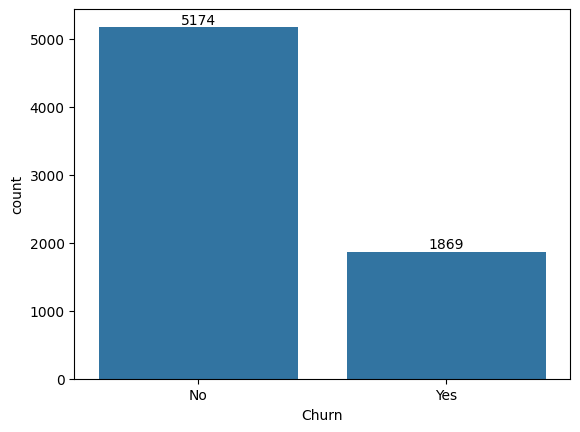

In [42]:
ax = sns.countplot(x = df['Churn'])
ax.bar_label(ax.containers[0])

#We can also check percentages of churns with the help of pie charts


#first convert it into groupby then make charts

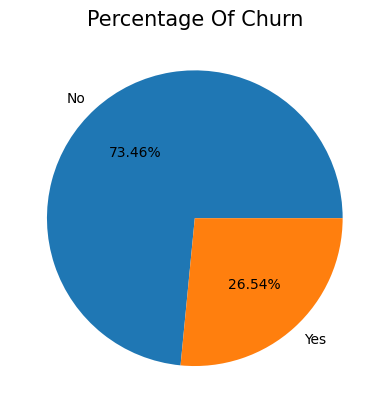

In [51]:
pi = df.groupby('Churn')['Churn'].value_counts()
plt.pie(pi , labels=pi.index , autopct = "%1.2f%%")
plt.title("Percentage Of Churn" , fontsize = 15)
plt.show()

#Here Our 26.54 % Customer are churn out or left our company  and what is reasion behind it let's find out ?




[Text(0, 0, '2549'), Text(0, 0, '2625')]

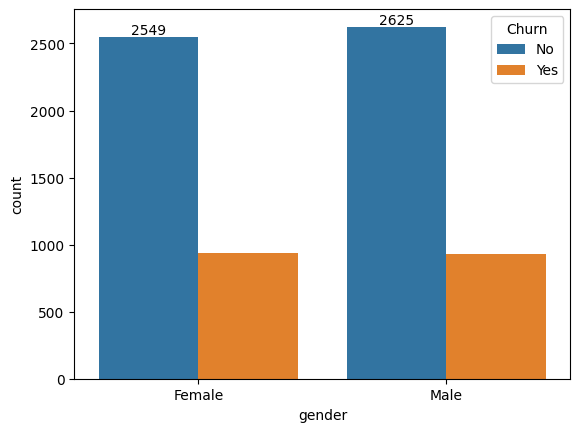

In [64]:
ax1 = sns.countplot(x = 'gender'  , data = df,hue='Churn')
ax1.bar_label(ax1.containers[0])

In [65]:

df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
No,5901
Yes,1142


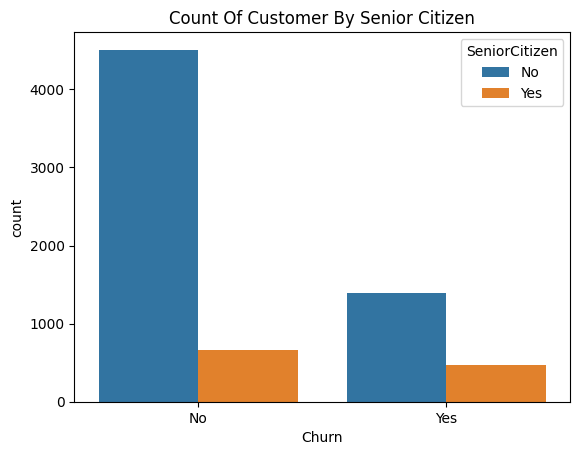

In [83]:
sns.countplot(data=df , x='Churn' , hue='SeniorCitizen')
plt.title("Count Of Customer By Senior Citizen")
plt.show()

#Comparative a greater percenta of people in senior citizen category have churned

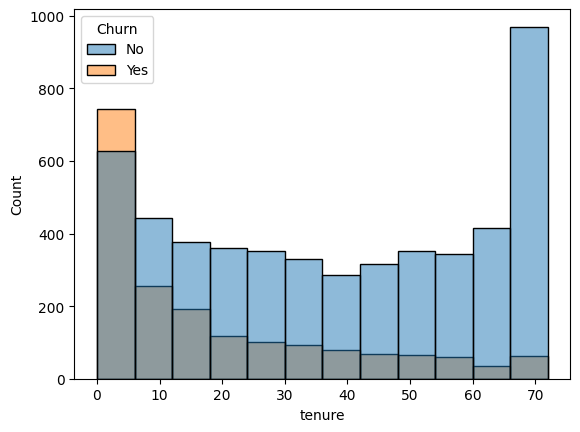

In [82]:
sns.histplot(data=df,x='tenure' , bins=12 , hue='Churn' )
plt.show()

#Most of people left in starting months
# People Who have used our services long term have stayed with us


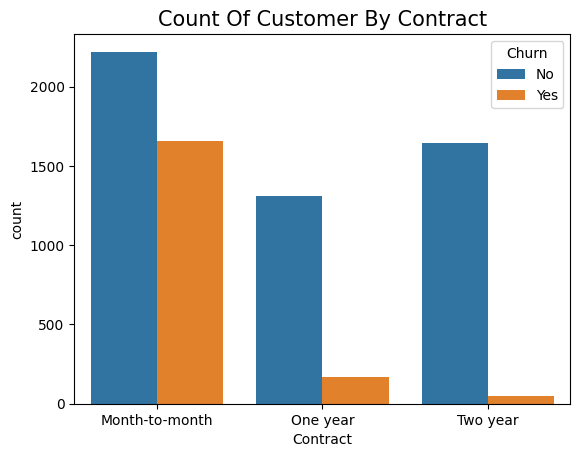

In [81]:
sns.countplot(data = df , x='Contract' , hue='Churn')
plt.title("Count Of Customer By Contract" , fontsize=15)
plt.show()

# People Who have month to month contracr exit mostly and Who Make contract for one and two year stay with us for long term and even not churn our company

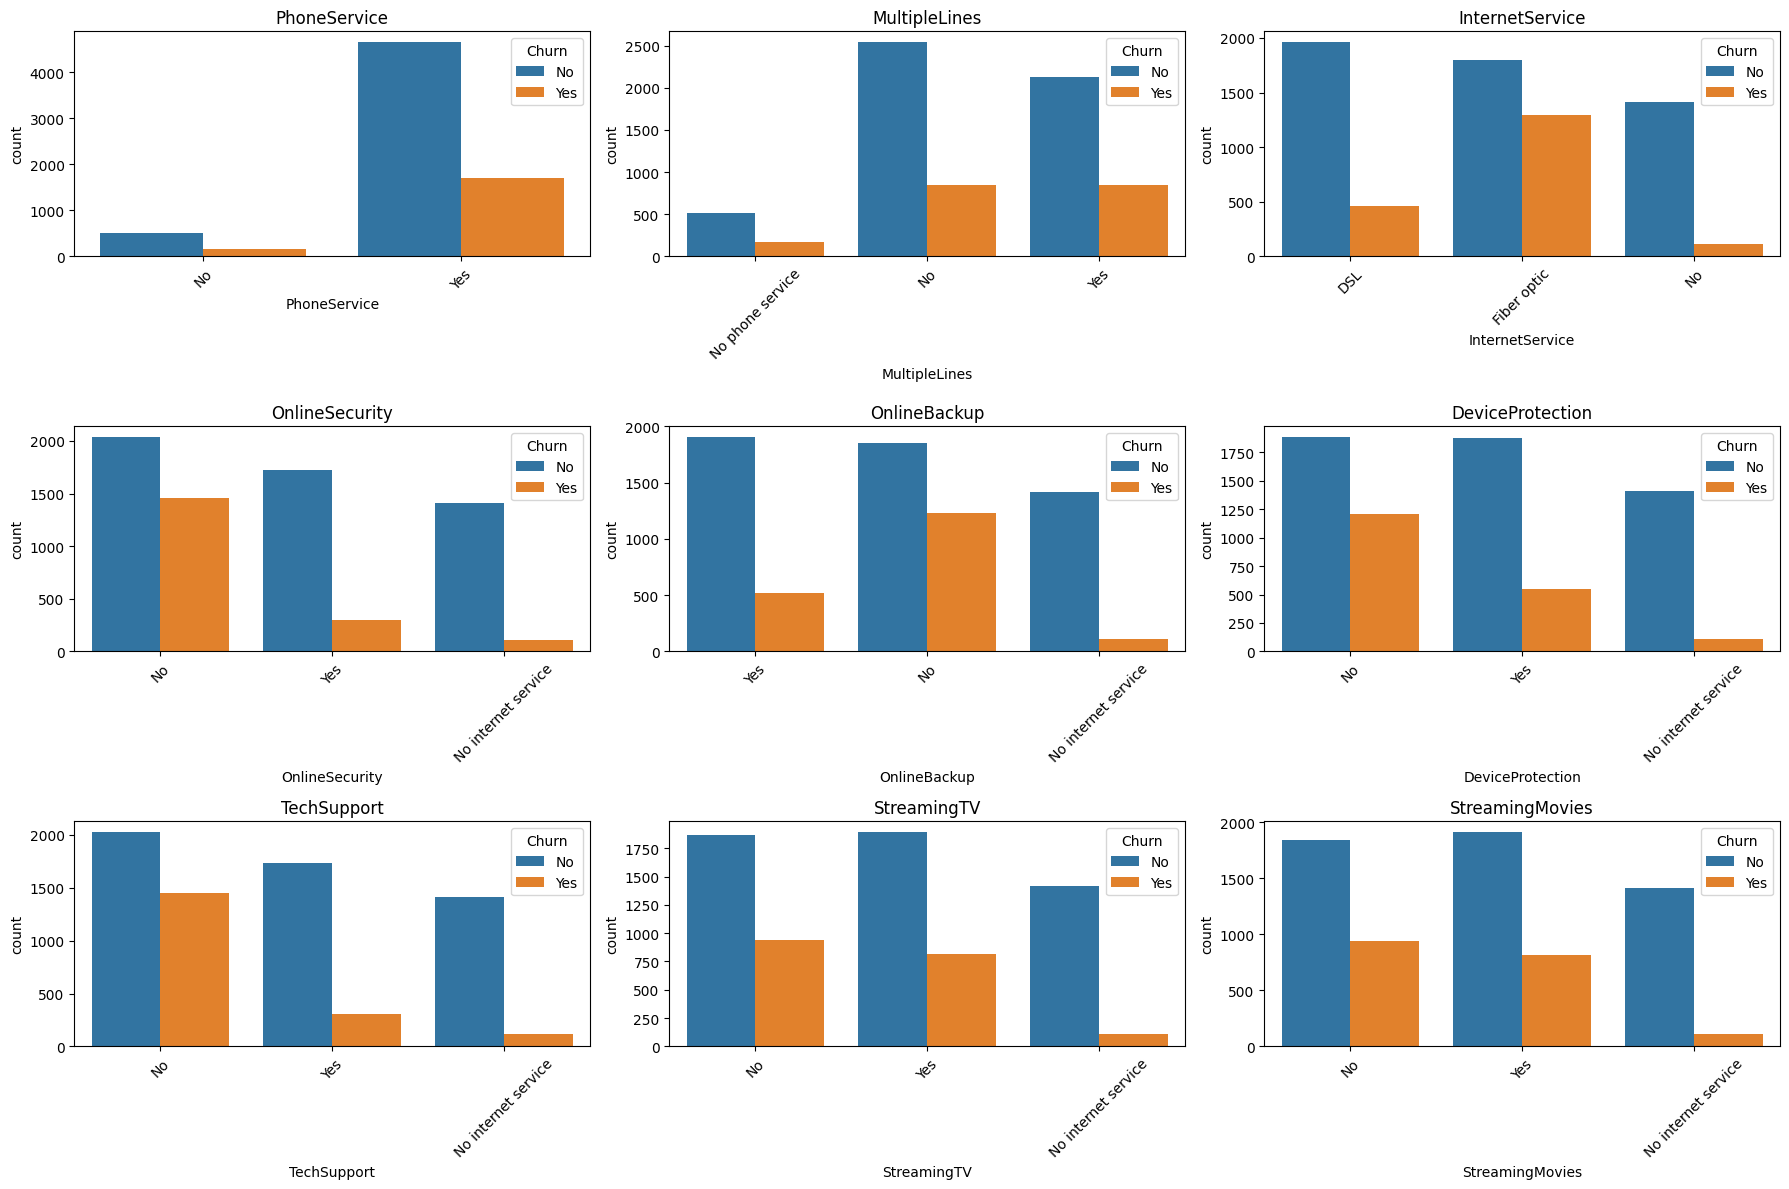

In [98]:
clm = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies']
fig, axes = plt.subplots(3,3, figsize=(18,12))

for ax, col in zip(axes.flatten(), clm):

    sns.countplot(x=col, hue="Churn", data=df, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1.	Customers without OnlineSecurity, TechSupport, or OnlineBackup show a much higher churn rate compared to those who have these services.
2.	Fiber optic InternetService users have noticeably higher churn than DSL users.
3.	Customers with No internet service generally show very low churn across features like StreamingTV, StreamingMovies, and DeviceProtection.
4.	Basic services like PhoneService and MultipleLines do not show a strong difference in churn compared to value-added services.

📊 Overall insight: Customers lacking support and security-related services are more likely to churn, while customers with additional services tend to stay longer.

In [95]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

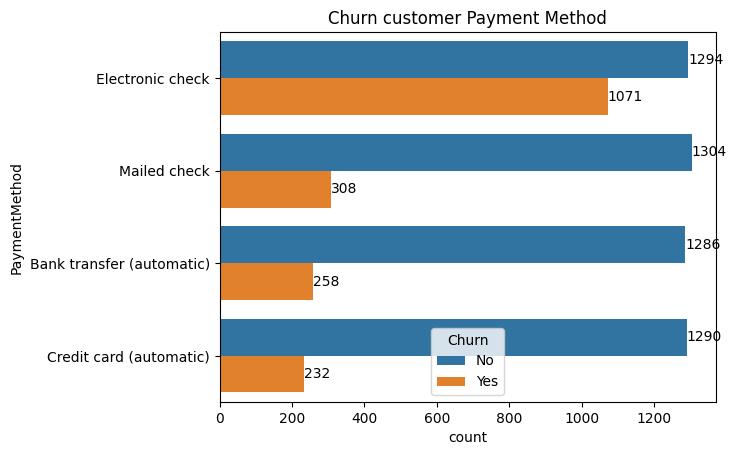

In [118]:
# df['PaymentMethod'].value_counts()
# df.groupby("PaymentMethod")['Churn'].value_counts()

# plt.figure(figsize=(10,6))
ax = sns.countplot(data = df  , y='PaymentMethod' , hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn customer Payment Method")
plt.show()

#Less Churn in automatic payment
# customer is likely to churn when it use Electronic Check